## Modelo XGBoost

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import confusion_matrix, cohen_kappa_score, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from scipy.sparse import csr_matrix
import itertools
from kennard_stone import train_test_split as ks_split
import os
import matplotlib.pyplot as plt

### 1. Definición del problema
El modelo utilizado en este análisis es XGBoost (*Extreme Gradient Boosting*), un algoritmo de machine learning basado en árboles de decisión y técnicas de *boosting*.

En lugar de construir un único árbol, XGBoost genera múltiples árboles secuenciales donde cada nuevo árbol corrige progresivamente los errores del anterior, mejorando así la capacidad predictiva del modelo.

El problema planteado corresponde a una tarea de clasificación binaria:
- Clase 1: PETasas termófilas
- Clase 0: PETasas no termófilas

El análisis comienza con la carga de la matriz dispersa global generada previamente durante la vectorización de *k*-mers. A partir de esta matriz se separan:
- **X:** matriz de características (*features*)
- **Y:** etiquetas de clasificación

De este modo, se define el conjunto de datos para el entrenamiento supervisado del modelo.

In [ ]:

# Leer mis archivos
input_file = "PETases_kmers_combo.xlsx"
output_prefix = "modelo"

# Cargar datos
TB = pd.read_excel(input_file, index_col=0)

# Etiqueta: termófilo o no 
obs = TB["Observations"].values

# Features: matriz TF-IDF de kmers
FE = TB.drop(columns=["Observations"])


In [3]:
# Separamos por clase
X = FE.values
y = obs

X_term = X[y==1] # termófilo
X_no_term = X[y==0] # no termófilo

### 2. Selección de datos

El siguiente paso consiste en dividir las muestras en conjuntos de entrenamiento y test para evaluar posteriormente el rendimiento del modelo.

Para ello se utilizó el algoritmo *Kennard–Stone split*, una estrategia de selección no aleatoria que prioriza la representatividad y diversidad de las muestras dentro del espacio de características.

Este método selecciona muestras que:
- Maximizan la diversidad en el espacio de *features*
- Cubren de forma más homogénea el espacio de datos
- Maximizar las distancias euclídeas entre muestras seleccionadas

Este enfoque es muy útil en datasets de alta dimensionalidad, como matrices basadas en *k*-mers, donde pueden existir agrupamientos (*clústers*) o distribuciones desbalanceadas.

In [ ]:
# Preparación del dataset para entrenamiento y evaluación del modelo

#  Selección representativa de 150 PETasas termófilas mediante Kennard-Stone
X_term_sel, X_term_rest, y_term_sel, y_term_rest = ks_split(X_term, np.ones(len(X_term)), train_size=150)

# Selección representativa de 150 PETasas no termófilas
X_no_sel, X_no_rest, y_no_sel, y_no_rest = ks_split(X_no_term, np.zeros(len(X_no_term)), train_size=150)

# # Construcción del dataset (300 proteínas)
X_300 = np.vstack([X_term_sel, X_no_sel]) # datos 
y_300 = np.concatenate([y_term_sel, y_no_sel]) # etiquetas

# División entrenamiento/validación usando nuevamente Kennard-Stone
X_train, X_val, y_train, y_val = ks_split(X_300, y_300, train_size=200)  # validación = 100 

# Conjunto de test externo:
# PETasas termófilas no están incluidas en la selección inicial
X_test = X_term_rest
y_test = y_term_rest

# Conversión a matriz dispersa
X_train = csr_matrix(X_train)
X_val = csr_matrix(X_val)
X_test = csr_matrix(X_test)


2026-04-30 11:33:44,548 - kennard_stone.utils._pairwise:114[INFO] - Calculating pairwise distances using scikit-learn.

2026-04-30 11:33:44,556 - kennard_stone.utils._pairwise:114[INFO] - Calculating pairwise distances using scikit-learn.

2026-04-30 11:33:44,623 - kennard_stone.utils._pairwise:114[INFO] - Calculating pairwise distances using scikit-learn.

2026-04-30 11:33:44,636 - kennard_stone.utils._pairwise:114[INFO] - Calculating pairwise distances using scikit-learn.

2026-04-30 11:33:44,725 - kennard_stone.utils._pairwise:114[INFO] - Calculating pairwise distances using scikit-learn.

2026-04-30 11:33:44,745 - kennard_stone.utils._pairwise:114[INFO] - Calculating pairwise distances using scikit-learn.



### 3. Modelado (*boosting* de árboles)

Antes del entrenamiento del modelo, se aplicó un ajuste de balanceo de clases para compensar posibles diferencias entre el número de PETasas termófilas y no termófilas.
Este ajuste permite evitar que el modelo favorezca sistemáticamente la clase mayoritaria, asignando un mayor peso a los errores cometidos sobre la clase minoritaria. De este modo, se mejora la capacidad del modelo para identificar correctamente PETasas termófilas.

Posteriormente, los conjuntos de entrenamiento y test fueron convertidos al formato optimizado utilizado por XGBoost, permitiendo una gestión más eficiente de matrices dispersas y datasets de alta dimensionalidad.

In [ ]:
# Peso de clases
pos = np.sum(obs == 1) # termófilos clase 1
neg = np.sum(obs == 0) # no termófilos clase 0
ratio = neg / pos

In [ ]:
# DMatrix 
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

### 4. Optimización y Evaluación

El siguiente paso consiste en definir un espacio de búsqueda de modelos mediante distintas combinaciones de hiperparámetros. Cada combinación representa un modelo potencial diferente que será evaluado.

Los hiperparámetros seleccionados controlan distintos aspectos del aprendizaje:

- **Estructura del árbol**
  - `max_depth`: profundidad máxima de los árboles y complejidad del modelo
  - `min_child_weight`: número mínimo de muestras requeridas para generar nuevos nodos

- **Regularización**
  - `gamma`: penalización aplicada a nuevas divisiones (*splits*)
  - `lambda`: regularización L2
  - `alpha`: regularización L1

- **Subsampling**
  - `subsample`: proporción de filas utilizadas en cada iteración
  - `colsample_bytree`: proporción de variables utilizadas por árbol

- **Aprendizaje**
  - `eta`: *learning rate* o velocidad de aprendizaje

La combinación de estos parámetros permite controlar el equilibrio entre sesgo y varianza (*bias–variance tradeoff*), evitando tanto el sobreajuste como la infraestimación del modelo.

Cada combinación de hiperparámetros fue evaluada mediante un proceso de búsqueda exhaustiva (*Grid Search*), donde se entrena y analiza un modelo distinto para cada configuración.

Para cada modelo se realizaron los siguientes pasos:

`Cross-validation`

Se aplicó validación cruzada de 5 particiones (*5-fold cross-validation*):
- El dataset se divide en 5 subconjuntos
- En cada iteración, el modelo se entrena utilizando 4 subconjuntos y se valida sobre el restante
- El proceso se repite hasta utilizar todos los subconjuntos como validación

Esta estrategia permite estimar el rendimiento del modelo de forma más robusta y reduce la dependencia de una única partición de entrenamiento/test.

`Número óptimo de árboles`

XGBoost construye árboles secuencialmente durante el entrenamiento. El número óptimo de árboles (`best_nrounds`) se determinó automáticamente a partir de los resultados de la validación cruzada.

`Función de pérdida` (*logloss*)

Se utilizó *logloss* como métrica de optimización, penalizando especialmente las predicciones incorrectas realizadas con alta confianza.

`Evaluación de predicciones`

Las probabilidades generadas por el modelo fueron convertidas posteriormente en clases binarias para analizar el comportamiento predictivo.

Se calcularon distintas métricas de rendimiento:

- **Sensibilidad (*recall*)**
  
  Mide la proporción de PETasas termófilas correctamente identificadas por el modelo

- **Kappa**
  
  Evalúa el grado de concordancia entre predicciones y valores reales corrigiendo el acuerdo esperado por azar.

In [ ]:
# Valores evaluados para cada hiperparámetro
xgbGrid = list(itertools.product(
    			[2,5,7,10], # max_depth
  				[1, 5],   # min_child_weight
  				[0.7,1], # subsample
				[0.6,0.9], # colsample_bytree
                [1e-3, 1e-2, 1e-1], # learning rate (eta)
                [1e-3, 1e-2, 1e-1, 5, 10], # gamma
				[0.01, 0.1, 1, 10, 100], # lambda
				[0, 0.001, 0.01, 0.1, 1, 10, 100])) # alpha

In [ ]:

# Nombre del archivo donde guardaremos el progreso
checkpoint_file = "progreso_grid_search.csv"

# Loop de optimización
for i, (max_depth, min_child_weight, subsample, colsample_bytree,
        eta, gamma, reg_lambda, alpha) in enumerate(xgbGrid):
    
    # Comprobar el estado de las iteraciones
    if os.path.exists(checkpoint_file):
        df_progreso = pd.read_csv(checkpoint_file)
        # Si el índice i ya está en el archivo, saltamos al siguiente
        if i in df_progreso['iteracion'].values:
            continue 
    # -----------------------------------------------------------

    params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "eta": eta,
        "max_depth": max_depth,
        "min_child_weight": min_child_weight,
        "subsample": subsample,
        "colsample_bytree": colsample_bytree,
        "gamma": gamma,
        "lambda": reg_lambda,
        "alpha": alpha,
        "scale_pos_weight": ratio,
        "nthread": 2
    }

    cv = xgb.cv(
        params=params,
        dtrain=dtrain,
        num_boost_round=1000,
        nfold=5,
        early_stopping_rounds=10,
        verbose_eval=False,
        seed=42
    )

    best_nrounds = len(cv)
    min_error = cv["test-logloss-mean"].min()

    model_tmp = xgb.train(params, dtrain, num_boost_round=best_nrounds)
    preds = model_tmp.predict(dtrain)
    pred_labels = (preds > 0.5).astype(int)

    cm = confusion_matrix(y_train, pred_labels)
    sensibility = cm[1,1] / cm[1].sum() if cm.shape == (2, 2) else np.nan
    kappa = cohen_kappa_score(y_train, pred_labels)

    # Creamos un diccionario con el resultado actual
    nuevo_resultado = {
        "iteracion": i,
        "max_depth": max_depth,
        "min_child_weight": min_child_weight,
        "subsample": subsample,
        "colsample_bytree": colsample_bytree,
        "eta": eta,
        "gamma": gamma,
        "lambda": reg_lambda,
        "alpha": alpha,
        "optntrees": best_nrounds,
        "minerror": min_error,
        "sensibilidad": sensibility,
        "kappa": kappa
    }

    
    # Convertimos a DataFrame y lo añadimos al CSV 
    df_item = pd.DataFrame([nuevo_resultado])
    # Si el archivo no existe, escribe cabecera; si existe, solo añade la fila
    df_item.to_csv(checkpoint_file, mode='a', index=False, header=not os.path.exists(checkpoint_file))
    
    print(f"Iteración {i} completada y guardada.")

# Al final del bucle, se carga todo el archivo para tener el 'results_df' final
results_df = pd.read_csv(checkpoint_file)

### 5. Modelo final

Una vez evaluadas todas las combinaciones de hiperparámetros, se seleccionó el modelo con el menor valor de *logloss*. Aunque también se calcularon métricas adicionales como sensibilidad (*recall*) y Kappa para evaluar el comportamiento del modelo, la selección final se basó en minimizar la función de pérdida.

Finalmente, el modelo definitivo fue entrenado utilizando:
- Todo el conjunto de entrenamiento
- La combinación óptima de hiperparámetros
- El número óptimo de árboles determinado durante la validación cruzada

Este modelo final se utilizó posteriormente para realizar predicciones sobre nuevos conjuntos de PETasas.

In [ ]:
results = pd.read_csv("progreso_grid_search.csv")

In [ ]:
# Selección mejor modelo
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("minerror")

best = results_df.iloc[0]

print("- Model with best hiperparameters -")
print(best)

- Model with best hiperparameters -
iteracion           16678.000000
max_depth              10.000000
min_child_weight        5.000000
subsample               1.000000
colsample_bytree        0.900000
eta                     0.100000
gamma                   0.010000
lambda                  1.000000
alpha                   1.000000
optntrees              25.000000
minerror                0.618603
sensibilidad            0.855263
kappa                   0.827586
Name: 16676, dtype: float64


In [ ]:
# Entrenamiento 
final_params = {
    "objective": "binary:logistic",
    "eta": best["eta"],
    "max_depth": int(best["max_depth"]),
    "min_child_weight": best["min_child_weight"],
    "subsample": best["subsample"],
    "colsample_bytree": best["colsample_bytree"],
    "alpha": best["alpha"],
    "lambda": best["lambda"],
    "gamma": best["gamma"],
    "scale_pos_weight": ratio,
    "verbosity": 0
}

final_model = xgb.train(
    params=final_params,
    dtrain=dtrain,
    num_boost_round=int(best["optntrees"])
)

### 6. Evaluación del modelo
Una vez entrenado el modelo final, se realizaron distintos análisis para evaluar su capacidad predictiva y explorar su comportamiento sobre nuevos conjuntos de datos.

Esta fase incluye:
- Evaluación del modelo, primero unicamente con la clase termófila y después con ambas clases
- La generación de predicciones utilizadas posteriormente en el mapa de predicciones
- El análisis del rendimiento global mediante curvas ROC y valores AUC
- La evaluación sobre un conjunto de test independiente

En conjunto, estos análisis permiten estimar tanto la capacidad de generalización del modelo como su utilidad para identificar PETasas potencialmente termófilas.

#### 6.1 Evaluación incial: clase termófila

In [ ]:
dtest = xgb.DMatrix(X_test)

# Probabilidades
y_pred_prob = final_model.predict(dtest)

# Transformamos a clases (umbral 0.5)
y_pred = (y_pred_prob > 0.5).astype(int)

In [12]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 0  0]
 [ 2 29]]
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       1.00      0.94      0.97        31

    accuracy                           0.94        31
   macro avg       0.50      0.47      0.48        31
weighted avg       1.00      0.94      0.97        31



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetr

#### 6.2 Evaluación final: clase termófila y clase no termófila

In [ ]:
# Test final (30 termófilas que no entraron en las 150 iniciales más 30 no termófilas)
X_test_mix = np.vstack([X_term_rest, X_no_rest[:31]])
y_test_mix = np.concatenate([y_term_rest, y_no_rest[:31]])

# Transformamos a matriz
X_test_mix = csr_matrix(X_test_mix)

In [ ]:
# Hacemos la predicción del modelo
dtest_mix = xgb.DMatrix(X_test_mix, label=y_test_mix)

# Probabilidades
y_pred_prob_mix = final_model.predict(dtest_mix)

# Transformamos a clases (umbral 0.5)
y_pred_mix = (y_pred_prob_mix > 0.5).astype(int)

In [15]:
print(confusion_matrix(y_test_mix, y_pred_mix))
print(classification_report(y_test_mix, y_pred_mix))

[[27  4]
 [ 2 29]]
              precision    recall  f1-score   support

         0.0       0.93      0.87      0.90        31
         1.0       0.88      0.94      0.91        31

    accuracy                           0.90        62
   macro avg       0.90      0.90      0.90        62
weighted avg       0.90      0.90      0.90        62



#### 6.3 Mapa de predicciones

In [ ]:
# Cargamos la tabla cambiando el index_col
DF_combo_vect = pd.read_excel("PETases_kmers_combo.xlsx", index_col="qseqid")

In [ ]:
# Ids de las PETasas termófilas y no termófilas usadas para la validación 
ids_term_rest = DF_combo_vect.index[150:181]
ids_no_term_rest = DF_combo_vect.index[331:362]

# Unimos en una unica lista
ids_mix = np.concatenate([ids_term_rest, ids_no_term_rest])

In [ ]:
# Creamos la tabla de resultados
resultados_test = pd.DataFrame({
    'qseqid': ids_mix,
    'real': y_test_mix,
    'prediccion': y_pred_mix
})

error = resultados_test[resultados_test['real'] != resultados_test['prediccion']]
print(f"Proteinas no predichas por el modelo: {error}")

Proteinas no predichas por el modelo:                                             qseqid  real  prediccion
16                                    MCS7112756.1   1.0           0
17      GCA_029776125.1_ASM2977612v1_genomic_00109   1.0           0
35                                      KKK39411.1   0.0           1
55                                    MCQ3030779.1   0.0           1
58  GCA_000341145.1_SOAPdenovo_v1.06_genomic_00437   0.0           1
61          GCA_000444215.1_BacSafVK_genomic_01041   0.0           1


In [ ]:
# Unimos las predicciones a archivo original
tb_original = pd.read_excel("Tabla_PETases.xlsx")
mapa_data = tb_original.merge(resultados_test, on="qseqid", how="left")

mapa_data.to_excel("PETasas_totales_con_predicciones.xlsx", index=False)

#### 6.4 Curva ROC y AUC

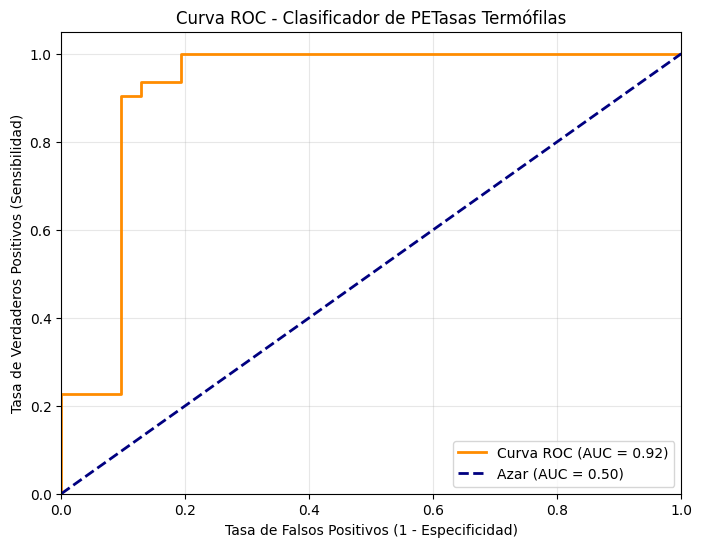

In [ ]:
# Cálculo de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test_mix, y_pred_prob_mix) # false positive rate / true posite rate 

# Cálculo del area bajo la curva
auc_value = roc_auc_score(y_test_mix, y_pred_prob_mix)

# Graficamos
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC - Clasificador de PETasas Termófilas')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

#### 6.5. Evaluación en el dataset de PETases de Uniprot

In [ ]:
tabla_pet = pd.read_excel("PETases_kmers_uniprot.xlsx", index_col=0) 
tabla_pet.head()

,aaa,aac,aad,aae,aaf,aag,aah,aai,aak,aal,...,yya,yyd,yye,yyg,yyl,yyn,yyp,yyq,yyr,yyt
"('A0A0K8P6T7', 'reviewed', 'Poly(ethylene terephthalate) hydrolase (PET hydrolase) (PETase) (EC 3.1.1.101) (PET-digesting enzyme)', 'ISF6_4831', 'Piscinibacter sakaiensis (Ideonella sakaiensis)', 290, 'MNFPRASRLMQAAVLGGLMAVSAAATAQTNPYARGPNPTAASLEASAGPFTVRSFTVSRPSGYGAGTVYYPTNAGGTVGAIAIVPGYTARQSSIKWWGPRLASHGFVVITIDTNSTLDQPSSRSSQQMAALRQVASLNGTSSSPIYGKVDTARMGVMGWSMGGGGSLISAANNPSLKAAAPQAPWDSSTNFSSVTVPTLIFACENDSIAPVNSSALPIYDSMSRNAKQFLEINGGSHSCANSGNSNQALIGKKGVAWMKRFMDNDTRYSTFACENPNSTRVSDFRTANCS', 'MNF NFP FPR PRA RAS ASR SRL RLM LMQ MQA QAA AAV AVL VLG LGG GGL GLM LMA MAV AVS VSA SAA AAA AAT ATA TAQ AQT QTN TNP NPY PYA YAR ARG RGP GPN PNP NPT PTA TAA AAS ASL SLE LEA EAS ASA SAG AGP GPF PFT FTV TVR VRS RSF SFT FTV TVS VSR SRP RPS PSG SGY GYG YGA GAG AGT GTV TVY VYY YYP YPT PTN TNA NAG AGG GGT GTV TVG VGA GAI AIA IAI AIV IVP VPG PGY GYT YTA TAR ARQ RQS QSS SSI SIK IKW KWW WWG WGP GPR PRL RLA LAS ASH SHG HGF GFV FVV VVI VIT ITI TID IDT DTN TNS NST STL TLD LDQ DQP QPS PSS SSR SRS RSS SSQ SQQ QQM QMA MAA AAL ALR LRQ RQV QVA VAS ASL SLN LNG NGT GTS TSS SSS SSP SPI PIY IYG YGK GKV KVD VDT DTA TAR ARM RMG MGV GVM VMG MGW GWS WSM SMG MGG GGG GGG GGS GSL SLI LIS ISA SAA AAN ANN NNP NPS PSL SLK LKA KAA AAA AAP APQ PQA QAP APW PWD WDS DSS SST STN TNF NFS FSS SSV SVT VTV TVP VPT PTL TLI LIF IFA FAC ACE CEN END NDS DSI SIA IAP APV PVN VNS NSS SSA SAL ALP LPI PIY IYD YDS DSM SMS MSR SRN RNA NAK AKQ KQF QFL FLE LEI EIN ING NGG GGS GSH SHS HSC SCA CAN ANS NSG SGN GNS NSN SNQ NQA QAL ALI LIG IGK GKK KKG KGV GVA VAW AWM WMK MKR KRF RFM FMD MDN DND NDT DTR TRY RYS YST STF TFA FAC ACE CEN ENP NPN PNS NST STR TRV RVS VSD SDF DFR FRT RTA TAN ANC NCS')",0.041279,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.020275,...,0.0,0.0,0.0,0.0,0.0,0.0,0.021493,0.0,0.0,0.0
"('E9LVH9', 'reviewed', 'Cutinase 2 (EC 3.1.1.74) (Poly(ethylene terephthalate) hydrolase) (PET hydrolase) (PETase) (EC 3.1.1.101)', 'cut2', 'Thermobifida cellulosilytica', 262, 'MANPYERGPNPTDALLEARSGPFSVSEERASRFGADGFGGGTIYYPRENNTYGAVAISPGYTGTQASVAWLGERIASHGFVVITIDTNTTLDQPDSRARQLNAALDYMINDASSAVRSRIDSSRLAVMGHSMGGGGTLRLASQRPDLKAAIPLTPWHLNKNWSSVRVPTLIIGADLDTIAPVLTHARPFYNSLPTSISKAYLELDGATHFAPNIPNKIIGKYSVAWLKRFVDNDTRYTQFLCPGPRDGLFGEVEEYRSTCPF', 'MAN ANP NPY PYE YER ERG RGP GPN PNP NPT PTD TDA DAL ALL LLE LEA EAR ARS RSG SGP GPF PFS FSV SVS VSE SEE EER ERA RAS ASR SRF RFG FGA GAD ADG DGF GFG FGG GGG GGT GTI TIY IYY YYP YPR PRE REN ENN NNT NTY TYG YGA GAV AVA VAI AIS ISP SPG PGY GYT YTG TGT GTQ TQA QAS ASV SVA VAW AWL WLG LGE GER ERI RIA IAS ASH SHG HGF GFV FVV VVI VIT ITI TID IDT DTN TNT NTT TTL TLD LDQ DQP QPD PDS DSR SRA RAR ARQ RQL QLN LNA NAA AAL ALD LDY DYM YMI MIN IND NDA DAS ASS SSA SAV AVR VRS RSR SRI RID IDS DSS SSR SRL RLA LAV AVM VMG MGH GHS HSM SMG MGG GGG GGG GGT GTL TLR LRL RLA LAS ASQ SQR QRP RPD PDL DLK LKA KAA AAI AIP IPL PLT LTP TPW PWH WHL HLN LNK NKN KNW NWS WSS SSV SVR VRV RVP VPT PTL TLI LII IIG IGA GAD ADL DLD LDT DTI TIA IAP APV PVL VLT LTH THA HAR ARP RPF PFY FYN YNS NSL SLP LPT PTS TSI SIS ISK SKA KAY AYL YLE LEL ELD LDG DGA GAT ATH THF HFA FAP APN PNI NIP IPN PNK NKI KII IIG IGK GKY KYS YSV SVA VAW AWL WLK LKR KRF RFV FVD VDN DND NDT DTR TRY RYT YTQ TQF QFL FLC LCP CPG PGP GPR PRD RDG DGL GLF LFG FGE GEV EVE VEE EEY EYR YRS RST STC TCP CPF')",0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.040050,0.0,0.028544,...,0.0,0.0,0.0,0.0,0.0,0.0,0.030259,0.0,0.0,0.0
"('F7IX06', 'reviewed', 'Cutinase est2 (EC 3.1.1.74) (Poly(ethylene terephthalate) hydrolase) (PET hydrolase) (PETase) (EC 3.1.1.101) (TaCut2)', 'est2 est119', 'Thermobifida alba (Thermomonospora alba)', 300, 'MSVTTPRRETSLLSRALRATAAAATAVVATVALAAPAQAANPYERGPNPTESMLEARSGPFSVSEERASRFGADGFGGGTIYYPRENNTYGAIAISPGYTGTQSSIAWLGERIASHGFVVIAIDTNTTLDQPDSRARQLNAALDYMLTDASSAVRNRIDASRLAVMGHSMGGGGTLRLASQRPDLKAAIPLTPWHLNKSWRDITVPTLIIGAEYDTIASVTLHSKPFYNSIPSPTDKAYLELDGASHFAPNITNKTIGMYSVAWLKRFVDEDTRYTQFLCPGPRTGLLSDVEEYRSTCPF', 'MSV SVT VTT TTP TPR PRR RRE RET ETS TSL SLL LLS LSR S

In [ ]:
# Test
uniprot_PET = tabla_pet.values
X_test_uniprot = uniprot_PET

# Transformamos a matriz
X_test_uniprot = csr_matrix(X_test_uniprot)

In [ ]:
# Hacemos la predicción del modelo
dtest_uniprot = xgb.DMatrix(X_test_uniprot)

# Probabilidades
y_pred_prob_uniprot = final_model.predict(dtest_uniprot)

# Transformamos a clases (umbral 0.5)
y_pred_uniprot = (y_pred_prob_uniprot > 0.5).astype(int)

In [19]:
# Cuantas predice como termófilas
print(f"Termófilas predichas: {sum(y_pred_uniprot)} de 473")

Termófilas predichas: 466 de 473


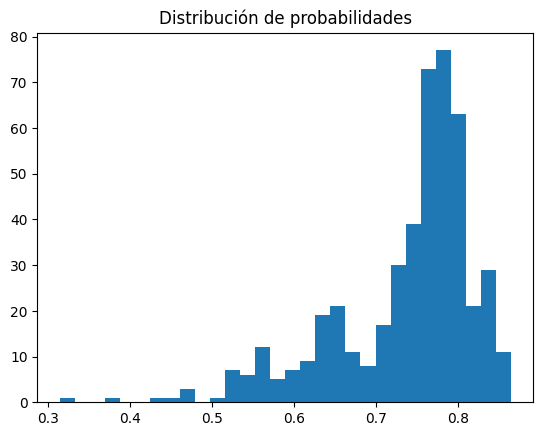

In [20]:
# Distribución de probabilidades
plt.hist(y_pred_prob_uniprot, bins=30)
plt.title("Distribución de probabilidades")
plt.show()

In [ ]:
# Top candidatos con diferentes umbrales de probabilidad
thresholds_top = [0.7, 0.8, 0.9]
for i in thresholds_top:
    high_conf = y_pred_prob_uniprot > i
    print(f"Umbral de {i}: {sum(high_conf)} proteínas")

Umbral de 0.7: 360 proteínas
Umbral de 0.8: 69 proteínas
Umbral de 0.9: 0 proteínas


#### 6.5.1 Top 10 de proteinas predichas como termófilas

In [ ]:
# Cargamos los datos de Uniprotkb y sincronizamos con las probabilidades del modelo
uniprot = pd.read_excel("uniprotkb_PETases.xlsx")
uniprot['probabilidad'] = y_pred_prob_uniprot

# Filtrado
# Ordenamos por probabilidad (de mayor a menor) y eliminamos organismos repetidos 
uniprot_unique = uniprot.sort_values(by='probabilidad', ascending=False).drop_duplicates(subset='Organism', keep='first')

# Selección del Top 10 de organismos únicos
top_10_unicos = uniprot_unique.head(10)

# Recuperamos los vectores originales
top_10_ids = top_10_unicos["Entry Name"].values
top_10_org = top_10_unicos["Organism"].values
top_10_probs = top_10_unicos["probabilidad"].values

# Visualización
print("--- TOP 10 CANDIDATOS ---")
for i in range(len(top_10_ids)):
    print(f"Entry: {top_10_ids[i]} | Organismo: {top_10_org[i]} | Confianza: {top_10_probs[i]:.4f}")

--- TOP 10 CANDIDATOS ---
Entry: H6WX58_9ACTN | Organismo: Thermobifida halotolerans | Confianza: 0.8639
Entry: A0ABY5DI48_9ACTN | Organismo: Nocardiopsis exhalans | Confianza: 0.8622
Entry: A0A840WFK4_9ACTN | Organismo: Nocardiopsis metallicus | Confianza: 0.8622
Entry: A0A918XC99_9ACTN | Organismo: Nocardiopsis kunsanensis | Confianza: 0.8583
Entry: A0A7Z0ENR9_9ACTN | Organismo: Nocardiopsis aegyptia | Confianza: 0.8563
Entry: A0A7C9P049_9ACTN | Organismo: Herbidospora solisilvae | Confianza: 0.8538
Entry: A0A4U3MNV4_9ACTN | Organismo: Herbidospora galbida | Confianza: 0.8503
Entry: A0ABW4SNQ3_9ACTN | Organismo: Nonomuraea mangrovi | Confianza: 0.8503
Entry: A0A365H6N6_9ACTN | Organismo: Actinomadura craniellae | Confianza: 0.8503
Entry: A0A5M3W626_9ACTN | Organismo: Acrocarpospora corrugata | Confianza: 0.8440
